In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

In [2]:
# import sp500 data 

sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(period="max")
sp500.columns = sp500.columns.get_level_values(0)


In [3]:
sp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


<Axes: xlabel='Date', ylabel='Close'>

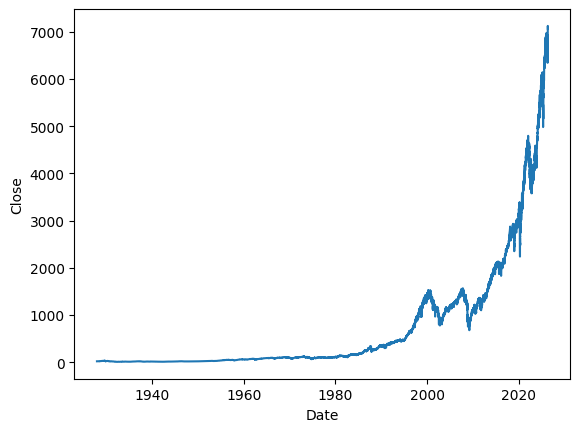

In [4]:
sns.lineplot(data=sp500, x=sp500.index, y=sp500["Close"])

## Data preprocessing

In [5]:
# remove unnecessary colums
sp500 = sp500.drop(columns={"Dividends", "Stock Splits"})
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000
2026-04-16 00:00:00-04:00,7037.779785,7051.229980,7008.520020,7041.279785,5173650000
2026-04-17 00:00:00-04:00,7074.549805,7147.520020,7074.549805,7126.060059,6145300000


In [6]:
# Remove Time and Timezone (Keep as Datetime)
sp500.index = sp500.index.tz_localize(None).floor('D')

In [7]:
# take the "Close" price of the next day and pulls it back to the current row
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [8]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785
2026-04-16,7037.779785,7051.229980,7008.520020,7041.279785,5173650000,7126.060059
2026-04-17,7074.549805,7147.520020,7074.549805,7126.060059,6145300000,7109.140137


In [9]:
# Add target column
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [10]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1
2026-04-16,7037.779785,7051.229980,7008.520020,7041.279785,5173650000,7126.060059,1
2026-04-17,7074.549805,7147.520020,7074.549805,7126.060059,6145300000,7109.140137,0


In [11]:
# remove old unusefull data (less thean "1990-01-01")
sp500 = sp500.loc["1990-01-01":].copy()

In [12]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1
2026-04-16,7037.779785,7051.229980,7008.520020,7041.279785,5173650000,7126.060059,1
2026-04-17,7074.549805,7147.520020,7074.549805,7126.060059,6145300000,7109.140137,0


## Build the model

#### Notes and explainations

 
min_samples_split=100 ==> This is a tool to prevent overfitting It tells a tree that it cannot split a node further
unless there are at least 100 data points in that node



n_estimators=100 ==> This tells the model to build 100 individual decision trees. Generally, more trees increase
the model's performance but make it slower to train


 
random_state=1 ==> This ensures reproducibility


In [13]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=2)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]

model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# Model Evaluation
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

preds = model.predict(test[predictors])

In [15]:
preds

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [16]:
preds = pd.DataFrame(preds, index=test.index)
preds = preds.rename(columns={0:"Model Predection"})

In [17]:
preds

,Model Predection
Date,
2025-11-25,1
2025-11-26,1
2025-11-28,0
2025-12-01,1
2025-12-02,1
...,...
2026-04-15,0
2026-04-16,0
2026-04-17,0


In [18]:
combined = pd.concat([test["Target"], preds], axis=1)
combined

,Target,Model Predection
Date,,
2025-11-25,1,1
2025-11-26,1,1
2025-11-28,0,0
2025-12-01,1,1
2025-12-02,1,1
...,...,...
2026-04-15,1,0
2026-04-16,1,0
2026-04-17,0,0


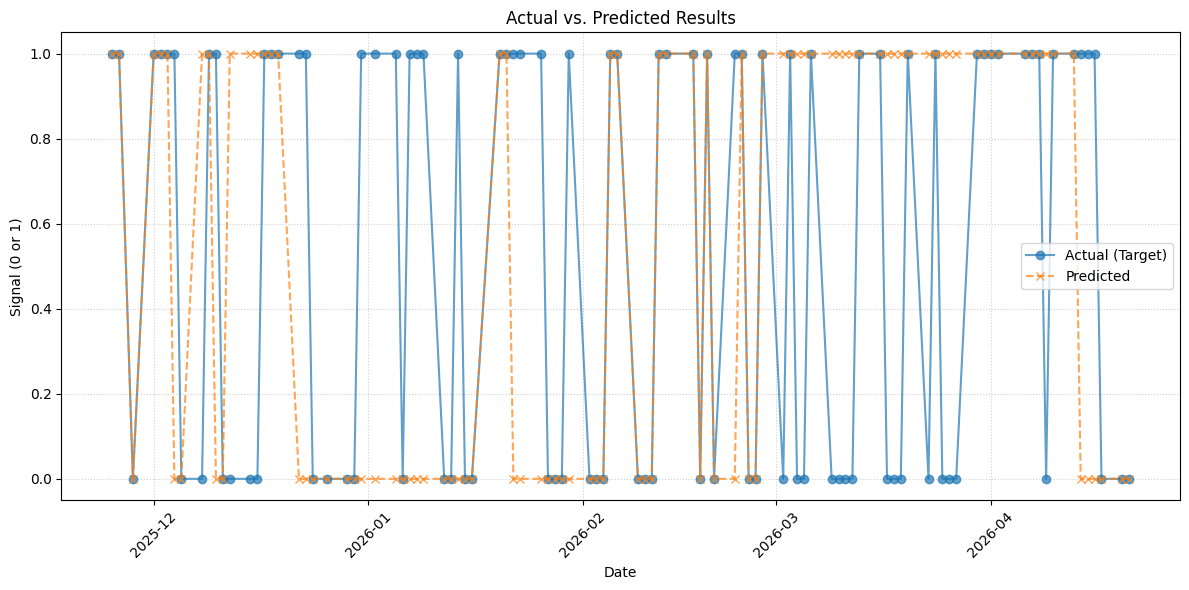

In [19]:
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'predictions'
plt.figure(figsize=(12, 6))

# Plotting both columns
plt.plot(combined.index, combined['Target'], label='Actual (Target)', marker='o', linestyle='-', alpha=0.7)
plt.plot(combined.index, combined['Model Predection'], label='Predicted', marker='x', linestyle='--', alpha=0.7)

plt.title('Actual vs. Predicted Results')
plt.xlabel('Date')
plt.ylabel('Signal (0 or 1)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

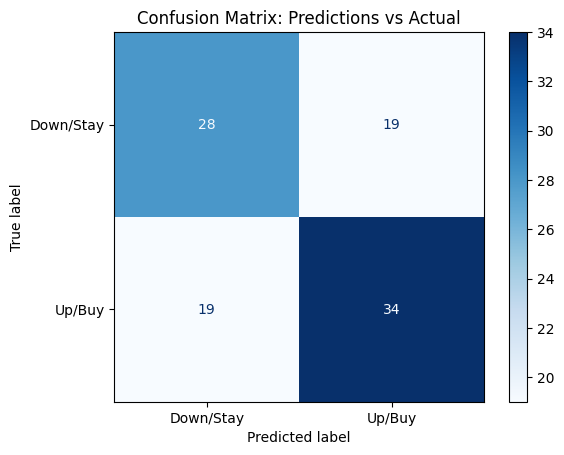

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the matrix
cm = confusion_matrix(combined['Target'], combined['Model Predection'])

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Stay', 'Up/Buy'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predictions vs Actual')
plt.show()

In [21]:
# create function that fit the model and combine the target column with prediction column

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    merged = pd.concat([test["Target"], preds], axis=1)

    return merged


In [22]:
predictions = predict(train, test, predictors, model)

In [23]:
predictions

,Target,Predictions
Date,,
2025-11-25,1,1
2025-11-26,1,1
2025-11-28,0,0
2025-12-01,1,1
2025-12-02,1,1
...,...,...
2026-04-15,1,0
2026-04-16,1,0
2026-04-17,0,0


In [24]:
accuracy_score(predictions["Target"], predictions["Predictions"])

0.62

In [25]:
precision_score(predictions["Target"], predictions["Predictions"])

0.6415094339622641

In [26]:
recall_score(predictions["Target"], predictions["Predictions"])

0.6415094339622641

In [27]:
f1_score(predictions["Target"], predictions["Predictions"])

0.6415094339622641

In [28]:
confusion_matrix(predictions["Target"], predictions["Predictions"])

array([[28, 19],
       [19, 34]])

## ADDING ADDITIONAL PREDICTORS TO OUR MODEL
(Feature Engineering)

In [29]:

vix_raw = yf.download("^VIX", start=sp500.index[0])

# 2. Extract only the 'Close' column and flatten it
# This ensures we have a simple column named "VIX"
if "Close" in vix_raw.columns:
    sp500["VIX"] = vix_raw["Close"]
else:
    # Handles cases where yfinance returns multi-index columns
    sp500["VIX"] = vix_raw.iloc[:, 0] 

# 3. Fill missing values (weekends/holidays)
sp500["VIX"] = sp500["VIX"].ffill()

# --- NOW START YOUR LOOP ---
horizens = [2, 5, 60]
new_predictores = []

for horizon in horizens:
    rolling_avgs = sp500.rolling(horizon).mean()
    
    # S&P 500 Ratios
    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_avgs["Close"]
    
    # VIX Ratios - THIS WILL NOW WORK
    vix_ratio_column = f"VIX_Ratio_{horizon}"
    sp500[vix_ratio_column] = sp500["VIX"] / rolling_avgs["VIX"]
    
    # Trend
    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictores += [ratio_column, trend_column, vix_ratio_column]

[*********************100%***********************]  1 of 1 completed


In [30]:
sp500 = sp500.dropna()

In [31]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,VIX,Close_Ratio_2,VIX_Ratio_2,Trend_2,Close_Ratio_5,VIX_Ratio_5,Trend_5,Close_Ratio_60,VIX_Ratio_60,Trend_60
Date,,,,,,,,,,,,,,,,,
1990-03-28,341.500000,342.579987,340.600006,342.000000,142300000,340.790009,0,19.770000,1.000732,0.969593,2.0,1.009421,0.954427,4.0,1.017666,0.884188,30.0
1990-03-29,342.000000,342.070007,339.769989,340.790009,132190000,339.940002,0,18.459999,0.998228,0.965734,1.0,1.002831,0.929600,4.0,1.014970,0.825434,30.0
1990-03-30,340.790009,341.410004,338.209991,339.940002,139340000,338.700012,0,19.730000,0.998751,1.033255,0.0,0.998731,1.000913,3.0,1.013229,0.881886,30.0
1990-04-02,339.940002,339.940002,336.329987,338.700012,124360000,343.640015,1,22.840000,0.998173,1.073056,0.0,0.994463,1.121697,2.0,1.010211,1.018824,30.0
1990-04-03,338.700012,343.760010,338.700012,343.640015,154310000,341.089996,0,20.440001,1.007240,0.944547,1.0,1.007701,1.009482,2.0,1.025463,0.911645,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-14,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1,18.360001,1.005857,0.979723,2.0,1.016305,0.944056,4.0,1.026374,0.852612,30.0
2026-04-15,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1,18.170000,1.003972,0.994799,2.0,1.017285,0.962700,4.0,1.034350,0.842283,31.0
2026-04-16,7037.779785,7051.229980,7008.520020,7041.279785,5173650000,7126.060059,1,17.940001,1.001303,0.993631,2.0,1.013579,0.966387,4.0,1.036428,0.833004,32.0


# Summary statistics

In [32]:
sp500.describe()

,Open,High,Low,Close,Volume,Tomorrow,Target,VIX,Close_Ratio_2,VIX_Ratio_2,Trend_2,Close_Ratio_5,VIX_Ratio_5,Trend_5,Close_Ratio_60,VIX_Ratio_60,Trend_60
count,9081.000000,9081.000000,9081.000000,9081.000000,9.081000e+03,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000,9081.000000
mean,1868.673083,1879.365019,1857.233302,1869.063821,2.613557e+09,1869.804049,0.537055,19.445323,1.000167,0.999982,1.074441,1.000691,1.000642,2.686158,1.010208,1.006480,32.229490
std,1503.957142,1511.355888,1495.955688,1504.218523,1.884485e+09,1505.120655,0.498652,7.782722,0.005691,0.033978,0.694351,0.011728,0.070213,1.061312,0.041604,0.207573,3.746948
min,295.450012,301.450012,294.510010,295.459991,0.000000e+00,295.459991,0.000000,9.140000,0.936260,0.782315,0.000000,0.897275,0.705597,0.000000,0.717536,0.576876,21.000000
25%,936.750000,943.849976,926.440002,936.590027,7.418000e+08,937.000000,0.000000,13.940000,0.997799,0.980943,1.000000,0.995176,0.959781,2.000000,0.992439,0.881898,30.000000
50%,1310.170044,1317.619995,1301.670044,1310.170044,2.872660e+09,1310.189941,1.000000,17.570000,1.000299,0.997868,1.000000,1.001617,0.994406,3.000000,1.016010,0.964228,32.000000
75%,2367.500000,2375.120117,2355.090088,2365.449951,3.963440e+09,2365.719971,1.000000,22.730000,1.002852,1.016260,2.000000,1.006994,1.034107,3.000000,1.036147,1.081938,35.000000
max,7117.049805,7147.520020,7084.410156,7126.060059,1.145623e+10,7126.060059,1.000000,82.690002,1.054731,1.366282,2.000000,1.087230,1.935082,5.000000,1.158054,3.706133,43.000000


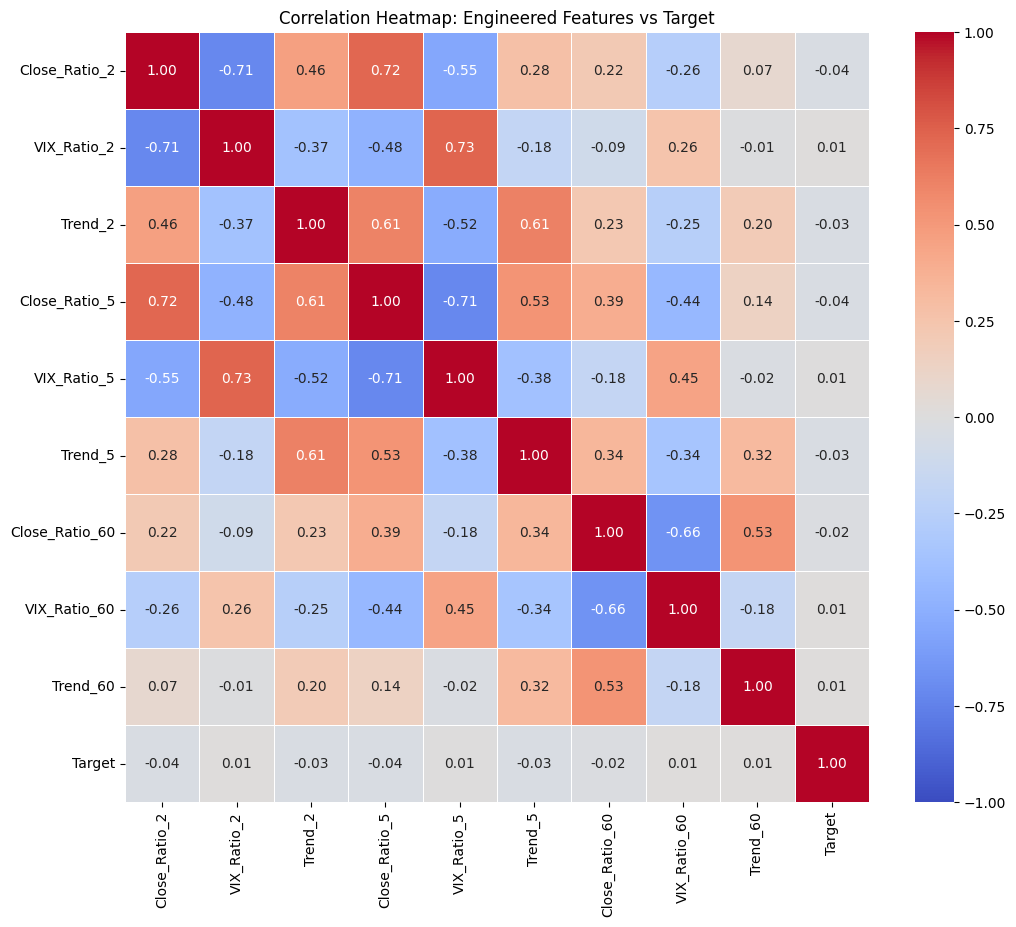

In [33]:

# 1. تحديد القائمة بالميزات الجديدة التي أنشأتها فقط + الهدف
# نستخدم list comprehension للبحث عن الأعمدة التي تحتوي على كلمات Trend أو Ratio
engineered_features = [col for col in sp500.columns if 'Trend' in col or 'Ratio' in col]
columns_to_analyze = engineered_features + ['Target']

# 2. حساب مصفوفة الارتباط
corr_matrix = sp500[columns_to_analyze].corr()

# 3. إعداد الرسم البياني
plt.figure(figsize=(12, 10))

# 4. رسم الخريطة الحرارية (Heatmap)
sns.heatmap(corr_matrix, 
            annot=True,            # إظهار الأرقام داخل المربعات
            fmt=".2f",             # تقريب الأرقام لخانين عشريتين
            cmap='coolwarm',       # لون أزرق للارتباط السالب وأحمر للموجب
            linewidths=0.5,        # إضافة فواصل بسيطة بين المربعات
            vmin=-1, vmax=1)       # تحديد نطاق الألوان من -1 إلى 1

plt.title('Correlation Heatmap: Engineered Features vs Target')
plt.show()

## IMPROVING OUR MODEL

In [34]:
# we change the parameters
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [35]:
def predict(train, test, new_predictores, model):

    model.fit(train[new_predictores], train["Target"])
    preds = model.predict_proba(test[new_predictores])[:,1]

    # modify the threshold
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    merged = pd.concat([test["Target"], preds], axis=1)

    return merged

In [36]:
# The function systematically moves through your dataset in chunks, training the model on all 
# data available up to a certain point and then testing it on the next immediate block of data.

# Because data from the past is not the same as data from the present; it is constantly changing.

# each 250 row represnts a one trading year 

# we train the model in the first 10 years and test it in the 11th year the train it in 11th year and test it in 12th year and so on....


def backtest(data, new_predictores, model, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):

        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()

        predictions = predict(train, test, new_predictores, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [37]:
predictions = backtest(sp500, new_predictores, model)

In [38]:
predictions.shape[0]

6581

In [39]:
accuracy_score(predictions["Target"], predictions["Predictions"])

0.4873119586688953

In [40]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5724444444444444

In [41]:
recall_score(predictions["Target"], predictions["Predictions"])

0.18207520497596832

In [42]:
f1_score(predictions["Target"], predictions["Predictions"])

0.27627627627627627

In [43]:
confusion_matrix(predictions["Target"], predictions["Predictions"])

array([[2563,  481],
       [2893,  644]])

In [44]:
preds

,Model Predection
Date,
2025-11-25,1
2025-11-26,1
2025-11-28,0
2025-12-01,1
2025-12-02,1
...,...
2026-04-15,0
2026-04-16,0
2026-04-17,0


In [45]:
preds = predictions

def precision_fig(preds):
    # 1. Filter and count
    buy_signals = preds[preds["Predictions"] == 1]
    counts = buy_signals["Target"].value_counts().sort_index()
    
    categories = ['Wrong (Price went Down)', 'Right (Price went Up)']
    values = [counts.get(0, 0), counts.get(1, 0)]

    # 2. Setup Theme & Layout
    sns.set_theme(style="dark", rc={
        "axes.facecolor": "#0d1117", 
        "figure.facecolor": "#0d1117",
        "grid.color": "#21262d"
    })
    plt.figure(figsize=(10, 6))
    
    # 3. Create the Plot (Fixed for v0.14.0 compatibility)
    ax = sns.barplot(
        x=categories, 
        y=values, 
        hue=categories, 
        legend=False, 
        palette=['#ef553b', '#00cc96']
    )

    # 4. ADD LABELS TO BOTH BARS
    # ax.containers[0] captures both the red and green bar objects
    ax.bar_label(ax.containers[0], color='white', padding=5, fontsize=12, weight='bold')

    # 5. Styling & Spacing
    plt.title("Outcome of 'Price Up' Predictions", color='white', weight='bold', loc='left', pad=25)
    plt.ylabel("Number of Days", color='white')
    
    # CRITICAL: Increase Y-limit so the labels don't hit the top of the box
    plt.ylim(0, max(values) * 1.15) 
    
    plt.xticks(color='white')
    plt.yticks(color='white')
    
    # Remove the box border for a cleaner "Plotly" look
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()


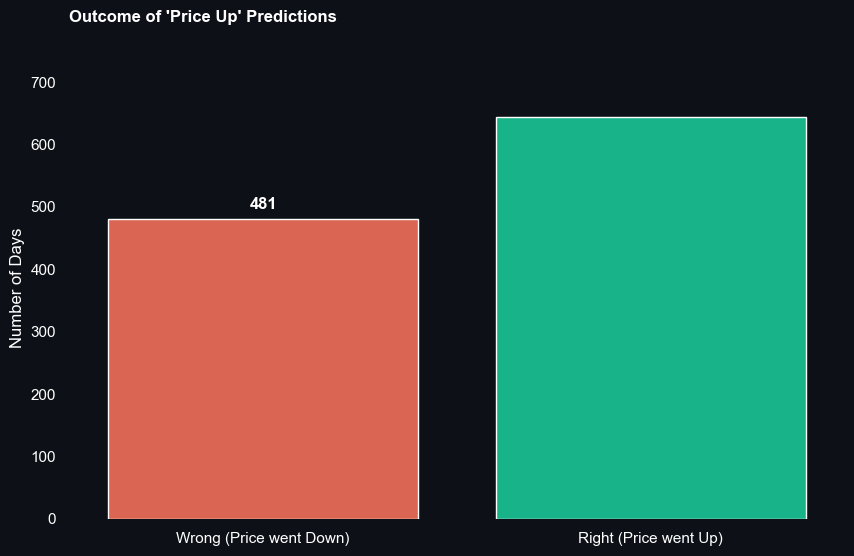

In [46]:
precision_fig(preds)

In [47]:
import xgboost as xgb

In [48]:
xgbc = xgb.XGBClassifier(n_estimators=200, min_child_weight=50, random_state=1)
model = xgbc

In [49]:
preds = backtest(sp500, new_predictores, model)

In [50]:
accuracy_score(preds["Target"], preds["Predictions"])

0.48989515271235373

In [51]:
precision_score(preds["Target"], preds["Predictions"])

0.5371593724194881

In [52]:
recall_score(preds["Target"], preds["Predictions"])

0.36782584110828387

In [53]:
f1_score(preds["Target"], preds["Predictions"])

0.4366504447054875

In [54]:
confusion_matrix(preds["Target"], preds["Predictions"])

array([[1923, 1121],
       [2236, 1301]])

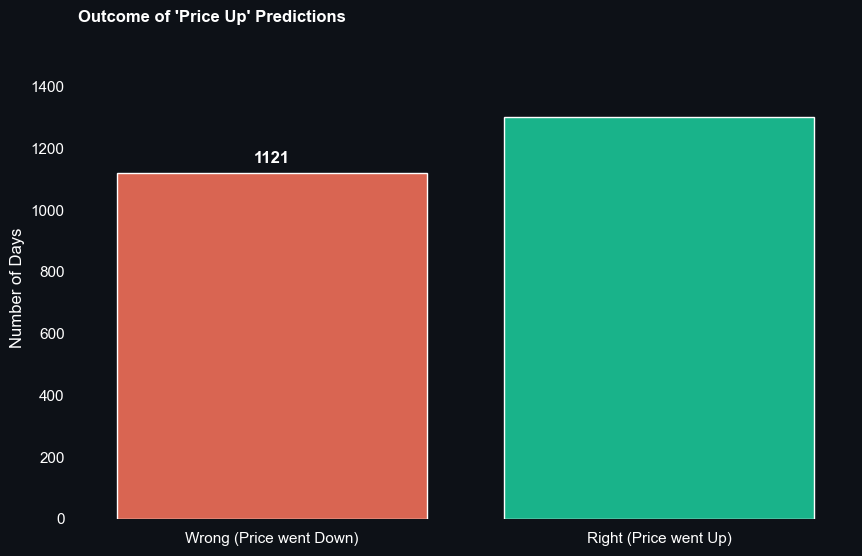

In [55]:
precision_fig(preds)

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# n_neighbors=10 looks at the 10 most similar historical days
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=10)
)

In [57]:
preds = backtest(sp500, new_predictores, model)

In [58]:
preds

,Target,Predictions
Date,,
2000-02-17,0,1.0
2000-02-18,1,0.0
2000-02-22,1,0.0
2000-02-23,0,0.0
2000-02-24,0,1.0
...,...,...
2026-04-14,1,0.0
2026-04-15,1,0.0
2026-04-16,1,0.0


In [59]:
accuracy_score(preds["Target"], preds["Predictions"])

0.4944537304361039

In [60]:
precision_score(preds["Target"], preds["Predictions"])

0.5333333333333333

In [61]:
recall_score(preds["Target"], preds["Predictions"])

0.47497879558948264

In [62]:
f1_score(preds["Target"], preds["Predictions"])

0.5024674742036788

In [63]:
confusion_matrix(preds["Target"], preds["Predictions"])

array([[1574, 1470],
       [1857, 1680]])

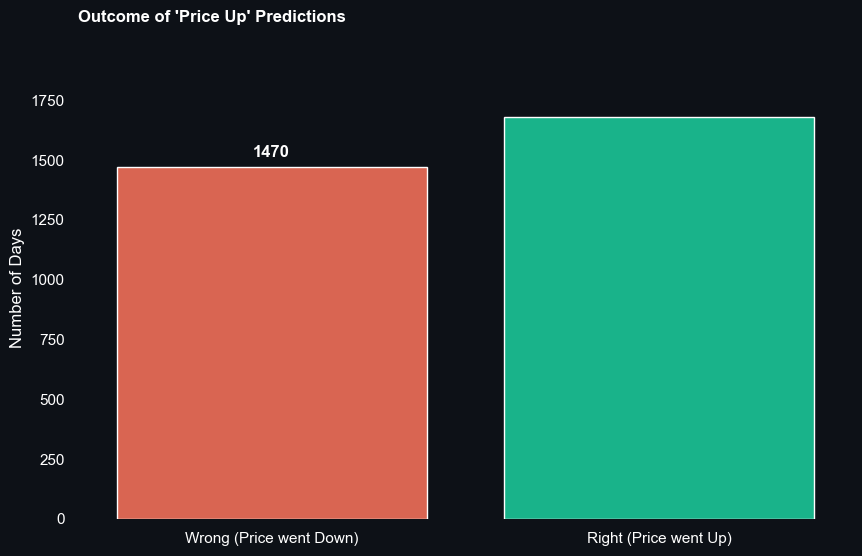

In [64]:
precision_fig(preds)